Make the installation and import necessary packages.

In [1]:
!pip install torch torchvision

In [ ]:
!pip install scikit-learn

In [16]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os
import seaborn as sns

In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Load the data

In [3]:
# converts PIL images to PyTorch tensors and rescales pixel values from 0–255 to 0–1
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# download CIFAR-10 and apply preprocessing
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# wrap in DataLoader for batching, shuffling, and paralel loading
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)

# same for the test set, but no shuffling needed
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:03<00:00, 43.9MB/s]


In [17]:
# CIFAR-10 class names
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Training samples: {len(trainset)}')
print(f'Test samples:     {len(testset)}')
print(f'Batch size:       {trainloader.batch_size}')
print(f'Classes:          {classes}')

Training samples: 50000
Test samples:     10000
Batch size:       32
Classes:          ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## Build the model

### Simple version of CNN model

In [5]:
# define a CNN by subclassing nn.Module
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# instantiate the model
net = Net()

### Improved version of CNN model

In [6]:
class ImprovedNet(nn.Module):
    def __init__(self):
        super(ImprovedNet, self).__init__()
        # Block 1: more filters + BatchNorm for stable training
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)    # padding=1 preserves spatial size
        self.bn1 = nn.BatchNorm2d(32)                   # normalizes activations per batch
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)

        # Block 2: deeper features
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Classifier with dropout to reduce overfitting
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)                   # randomly zeros 50% of neurons
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 32x32 → 16x16
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 16x16 → 8x8
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 8x8 → 4x4
        x = x.view(-1, 128 * 4 * 4)                     # Flatten
        x = self.dropout(F.relu(self.fc1(x)))            # Dense + ReLU + Dropout
        x = self.fc2(x)                                  # Raw logits
        return x

improved_net = ImprovedNet()

## Train the model

In [7]:
# loss function for both models
criterion = nn.CrossEntropyLoss()

In [10]:
# separate optimizers
optimizer_basic = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
optimizer_improved = optim.SGD(improved_net.parameters(), lr=0.001, momentum=0.9)

In [18]:
EPOCHS = 10

In [11]:
# define train function
def train_model(model, optimizer, trainloader, epochs=10, model_name="Model"):
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data

            optimizer.zero_grad()          # Reset gradients from previous step
            outputs = model(inputs)        # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()                # Backward pass (compute gradients)
            optimizer.step()               # Update weights

            running_loss += loss.item()
            if i % 2000 == 1999:           # Print every 2000 batches
                print(f'[{model_name} - Epoch {epoch + 1}, Batch {i + 1}] '
                      f'loss: {running_loss / 2000:.3f}')
                running_loss = 0.0

    print(f'{model_name} — Finished Training\n')

In [13]:
# start training for both models
print("=" * 50)
print("Training BasicCNN...")
print("=" * 50)
loss_basic = train_model(net, optimizer_basic, trainloader, epochs=EPOCHS, model_name="BasicCNN")

print("=" * 50)
print("Training ImprovedCNN...")
print("=" * 50)
loss_improvedd = train_model(improved_net, optimizer_improved, trainloader, epochs=EPOCHS, model_name="ImprovedCNN")

Training BasicCNN...
BasicCNN — Finished Training

Training ImprovedCNN...
ImprovedCNN — Finished Training



## Training Loss Comparison

In [19]:
# Plot training loss curves side by side
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), loss_basic, 'o-', label='BasicCNN', color='coral')
plt.plot(range(1, EPOCHS + 1), loss_improved, 's-', label='ImprovedCNN', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'loss_basic' is not defined

<Figure size 1000x500 with 0 Axes>

## Evaluate the model

In [24]:
# define an evaluation function that returns accuracy, precision, recall, confusion matrix etc.
def full_evaluation(model, testloader, model_name="Model"):
    all_predictions = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.numpy())   # Collect all predictions
            all_labels.extend(labels.numpy())            # Collect all true labels

    model.train()

    # Overall accuracy
    accuracy = 100 * np.sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)
    print(f"\n{'=' * 60}")
    print(f" {model_name} — Full Evaluation")
    print(f"{'=' * 60}")
    print(f"Overall Accuracy: {accuracy:.2f}%\n")

    # Per-class precision, recall, F1-score
    print("Classification Report:")
    print(classification_report(all_labels, all_predictions, target_names=classes))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)


    return accuracy, all_predictions, all_labels, cm


In [25]:
# start evaluating for both models
print("=" * 50)
acc_basic, preds_basic, labels_basic, cm_basic = full_evaluation(net, testloader, "BasicCNN")
acc_improved, preds_improved, _, cm_improved = full_evaluation(improved_net, testloader, "ImprovedCNN")


 BasicCNN — Full Evaluation
Overall Accuracy: 58.44%

Classification Report:
              precision    recall  f1-score   support

       plane       0.67      0.62      0.64      1000
         car       0.76      0.66      0.71      1000
        bird       0.55      0.35      0.43      1000
         cat       0.43      0.37      0.40      1000
        deer       0.39      0.68      0.50      1000
         dog       0.61      0.32      0.42      1000
        frog       0.71      0.65      0.68      1000
       horse       0.55      0.72      0.63      1000
        ship       0.68      0.80      0.73      1000
       truck       0.65      0.68      0.66      1000

    accuracy                           0.58     10000
   macro avg       0.60      0.58      0.58     10000
weighted avg       0.60      0.58      0.58     10000


 ImprovedCNN — Full Evaluation
Overall Accuracy: 77.03%

Classification Report:
              precision    recall  f1-score   support

       plane       0.77    

In [26]:
# Side-by-side summary
print('\n' + '=' * 60)
print('COMPARISON SUMMARY')
print('=' * 60)
print(f'BasicCNN:    {acc_basic:.2f}%')
print(f'ImprovedCNN: {acc_improved:.2f}%')
print(f'Improvement: +{acc_improved - acc_basic:.2f}%')


COMPARISON SUMMARY
BasicCNN:    58.44%
ImprovedCNN: 77.03%
Improvement: +18.59%


## Confusion Matrix Visualization

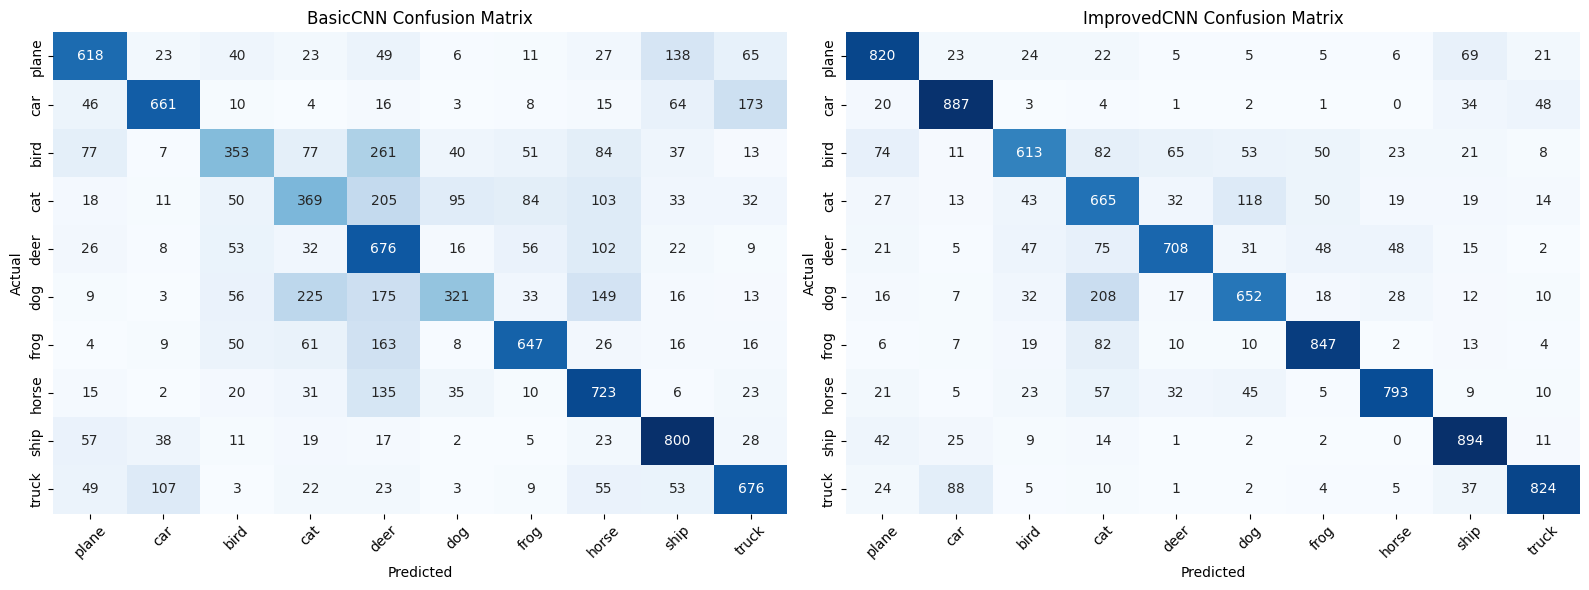

In [27]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cm, name in zip(axes, [cm_basic, cm_improved], ['BasicCNN', 'ImprovedCNN']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes,
                yticklabels=classes, ax=ax, cbar=False)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Per-Class Accuracy Comparison

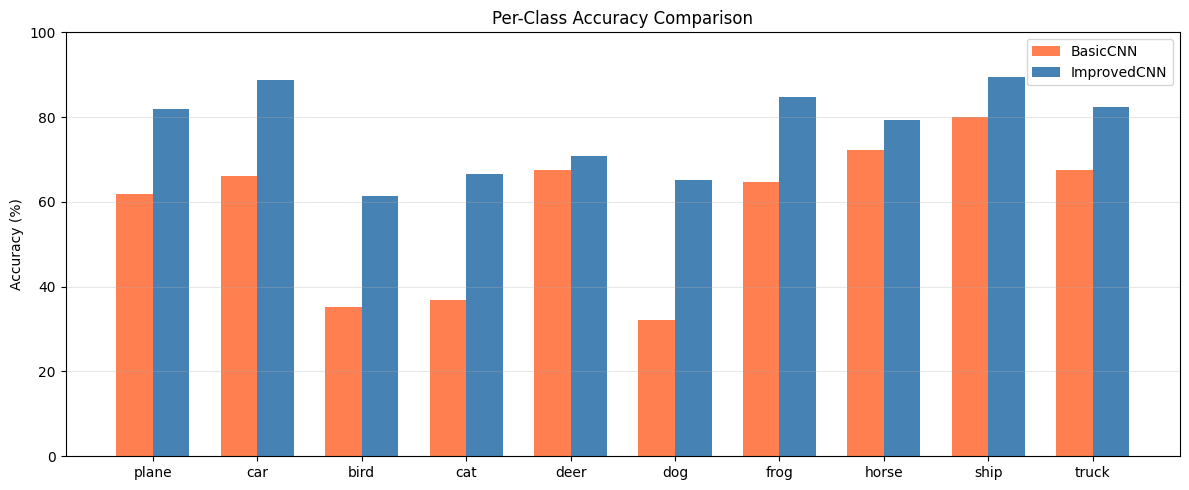

In [28]:
# Compute per-class accuracy for both models
per_class_basic = cm_basic.diagonal() / cm_basic.sum(axis=1) * 100
per_class_improved = cm_improved.diagonal() / cm_improved.sum(axis=1) * 100

# Bar chart comparison
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, per_class_basic, width, label='BasicCNN', color='coral')
bars2 = ax.bar(x + width/2, per_class_improved, width, label='ImprovedCNN', color='steelblue')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Save & Load the models securely

In [29]:
# save state_dict (weights only), NOT the full model
# torch.save(model) uses pickle which is vulnerable to arbitrary code execution
PATH_BASIC = './basiccnn_cifar10.pth'
PATH_IMPROVED = './improvedcnn_cifar10.pth'

torch.save(net.state_dict(), PATH_BASIC)
torch.save(improved_net.state_dict(), PATH_IMPROVED)
print("Both models saved.")

Both models saved.


In [33]:
# Always define the architecture first, then load weights into it
# NEVER use torch.load() on files from untrusted sources

# Re-create architectures first, then load weights
basic_model_loaded = Net().to(device)
improved_model_loaded = ImprovedNet().to(device)

# weights_only=True blocks pickle-based code injection from malicious .pth files
# map_location ensures it works regardless of where the model was originally saved (CPU/GPU)
basic_model_loaded.load_state_dict(
    torch.load(PATH_BASIC, weights_only=True, map_location=device)
)
improved_model_loaded.load_state_dict(
    torch.load(PATH_IMPROVED, weights_only=True, map_location=device)
)

<All keys matched successfully>